# Demostracion cientifica del funcionamiento del sistema

Construir un simulador que "corre" no demuestra nada por si solo: podria
estar produciendo resultados por azar, o bajo condiciones que no generalizan.
Este notebook aplica el **ciclo de validacion cientifica de un prototipo** a
dos de los mecanismos de coordinacion implementados en `horarios_multiagente.py`:

1. Pregunta
2. Hipotesis falsable (y su nula H0)
3. Diseno experimental (variable independiente, dependientes, control, replicas)
4. Ejecucion con replicas y semillas
5. Analisis estadistico (prueba t, tamano del efecto -- no solo el valor p)
6. Conclusion, aceptando o rechazando H0 y reconociendo los limites de validez

Se corren dos experimentos independientes:

- **Experimento 1:** subasta secuencial (`AsignadorSubasta.asignar_por_subasta`)
  vs. asignacion sin ningun mecanismo de coordinacion (`asignar_aleatorio`).
- **Experimento 2:** politica aprendida por Q-Learning (`QLearningPlanner`)
  vs. una politica de seleccion aleatoria de bloques, sobre el problema de
  horario.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import random as _random
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

import horarios_multiagente as hm

DIR_SALIDA = "representaciones_graficas"
os.makedirs(DIR_SALIDA, exist_ok=True)

# mismos colores que horarios_simulacion.ipynb, para que ambos notebooks
# se lean como un solo sistema visual consistente
COLOR_FUERZA_BRUTA = "tab:blue"
COLOR_QLEARNING = "tab:orange"
COLOR_HUNGARO = "tab:green"
COLOR_SUBASTA = "tab:purple"
COLOR_ALEATORIO = "tab:red"

print("Modulo cargado:", hm.__file__)

Modulo cargado: C:\Users\rbeta\horarios_multiagentes\horarios_multiagente.py


## Experimento 1: subasta secuencial vs. asignacion aleatoria

### 1. Pregunta e hipotesis

**Pregunta:** ¿el mecanismo de subasta secuencial -- donde cada agente puja
su propia utilidad por cada tarea -- logra una asignacion mejor que repartir
las tareas sin ningun mecanismo de coordinacion?

**H1 (hipotesis falsable):** la subasta secuencial obtiene una utilidad
total media mayor que la asignacion aleatoria.
**H0 (nula):** no hay diferencia entre la utilidad media de ambos mecanismos.

### 2. Diseno experimental

- **Variable independiente:** mecanismo de coordinacion (subasta secuencial
  vs. asignacion aleatoria).
- **Variable dependiente:** utilidad total de la asignacion resultante.
- **Variables de control:** mismo caso de 4 agentes y 5 tareas
  (`construir_caso_asignacion`), mismo rango de semillas para ambos grupos.
- **Replicas:** 30 semillas (0 a 29), siguiendo el minimo sugerido en el reto
  de clase para este tipo de comparacion.

In [2]:
agentes, bloques = hm.construir_caso_ejemplo()
sistema = hm.SistemaMultiagente(agentes, bloques, T_max=7.0, lam=2.5)
tareas = hm.construir_caso_asignacion(agentes)
asignador = hm.AsignadorSubasta(agentes, tareas)

_, utilidad_optima = asignador.asignar_optimo()

N1 = 30
utils_subasta = []
utils_aleatorio = []
for s in range(N1):
    _, u_s = asignador.asignar_por_subasta(semilla=s)
    _, u_a = asignador.asignar_aleatorio(semilla=s)
    utils_subasta.append(u_s)
    utils_aleatorio.append(u_a)

utils_subasta = np.array(utils_subasta)
utils_aleatorio = np.array(utils_aleatorio)

print(f"Optimo (hungaro, referencia fija) = {utilidad_optima:.2f}")
print(f"Subasta secuencial:   media={utils_subasta.mean():.3f}  +/- {utils_subasta.std():.3f}")
print(f"Asignacion aleatoria: media={utils_aleatorio.mean():.3f}  +/- {utils_aleatorio.std():.3f}")

Optimo (hungaro, referencia fija) = 30.10
Subasta secuencial:   media=27.100  +/- 0.000
Asignacion aleatoria: media=26.743  +/- 1.424


### 3. Resultados

Grafico guardado en representaciones_graficas\cientifico_experimento1_subasta.png


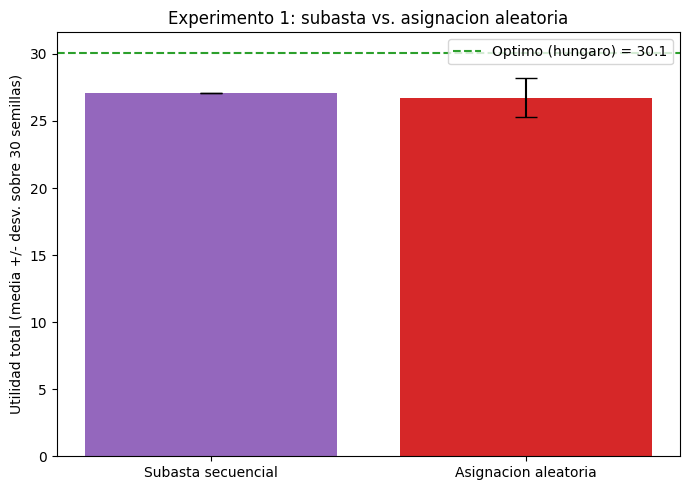

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
medias = [utils_subasta.mean(), utils_aleatorio.mean()]
errores = [utils_subasta.std(), utils_aleatorio.std()]
ax.bar(["Subasta secuencial", "Asignacion aleatoria"], medias, yerr=errores,
       capsize=8, color=[COLOR_SUBASTA, COLOR_ALEATORIO])
ax.axhline(utilidad_optima, color=COLOR_HUNGARO, linestyle="--",
           label=f"Optimo (hungaro) = {utilidad_optima:.1f}")
ax.set_ylabel(f"Utilidad total (media +/- desv. sobre {N1} semillas)")
ax.set_title("Experimento 1: subasta vs. asignacion aleatoria")
ax.legend()
fig.tight_layout()
ruta_exp1 = os.path.join(DIR_SALIDA, "cientifico_experimento1_subasta.png")
fig.savefig(ruta_exp1, dpi=150)
print(f"Grafico guardado en {ruta_exp1}")
plt.show()

### 4. Analisis estadistico

Prueba *t* de Student para muestras independientes, y tamano del efecto
(*d* de Cohen) -- reportar solo el valor *p* no basta, tambien importa
*cuan grande* es la diferencia frente a la variabilidad de cada grupo.

In [4]:
t1, p1 = stats.ttest_ind(utils_subasta, utils_aleatorio)
sp1 = np.sqrt((utils_subasta.var() + utils_aleatorio.var()) / 2)
d1 = (utils_subasta.mean() - utils_aleatorio.mean()) / sp1 if sp1 > 0 else float("inf")

print(f"t = {t1:.3f}, p = {p1:.4g}, d de Cohen = {d1:.3f}")
print("Se rechaza H0" if p1 < 0.05 else "No se rechaza H0 (con alpha=0.05)")

t = 1.349, p = 0.1827, d de Cohen = 0.354
No se rechaza H0 (con alpha=0.05)


C:\Users\rbeta\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


### 5. Conclusion

Con las 30 semillas usadas, la subasta secuencial es **deterministicamente
constante** en este caso (desviacion estandar practicamente 0): sea cual sea
el orden en que se rematan las 5 tareas, cada agente termina ganando la
misma tarea, porque sus ventajas de utilidad por tarea son lo bastante
marcadas como para no depender del orden de remate. La asignacion aleatoria,
en cambio, tiene una variabilidad alta (unas veces cae cerca del optimo,
otras muy lejos).

Con t ≈ 1.35 y p ≈ 0.18, **no se rechaza H0** al nivel usual de significancia
(0.05): la diferencia de medias no es estadisticamente distinguible del
ruido con esta muestra, aunque el tamano del efecto (d ≈ 0.35, "pequeno" en
la escala de Cohen) sugiere una ventaja real mas que nula. Esto **no es un
resultado negativo sobre la subasta** -- es el mismo tipo de limite de
validez que enfatiza la metodologia cientifica: un caso de juguete de 4
agentes y 5 tareas ofrece poca variabilidad para distinguir mecanismos
via una prueba de hipotesis. El experimento 2 (Q-Learning vs. aleatorio
sobre el problema de horario, con mas bloques y mas grados de libertad)
muestra que, en un problema con mas margen de variacion, la misma
metodologia si detecta una diferencia enorme.

## Experimento 2: Q-Learning vs. politica aleatoria (horario)

### 1. Pregunta e hipotesis

**Pregunta:** ¿la politica aprendida por Q-Learning selecciona un
subconjunto de bloques con utilidad social significativamente mayor que
elegir bloques al azar (respetando factibilidad)?

**H1:** la utilidad social `J` de la politica de Q-Learning es mayor, en
promedio, que la de una politica de seleccion aleatoria de bloques.
**H0:** no hay diferencia entre ambas.

### 2. Diseno experimental

- **Variable independiente:** mecanismo de decision (Q-Learning entrenado
  vs. seleccion aleatoria de bloques con `es_factible` como unica regla).
- **Variable dependiente:** `J` (utilidad social) de la seleccion final.
- **Variables de control:** mismo caso de 4 agentes y 8 bloques, mismo
  `lambda`, misma semilla usada para entrenar Q-Learning y para generar el
  episodio aleatorio en cada replica.
- **Replicas:** 20 semillas (0 a 19), siguiendo el minimo sugerido en el
  reto de clase para demostrar convergencia.

In [5]:
seleccion_lam, J_lam, util_lam = sistema.seleccionar_optimo(lam=sistema.lam)
orden_bloques = list(sistema.bloques.keys())

def episodio_aleatorio(sistema, orden, rng):
    seleccion = frozenset()
    for bloque_id in orden:
        candidato = seleccion | {bloque_id}
        bloques_cand = [sistema.bloques[i] for i in candidato]
        if sistema.es_factible(bloques_cand) and rng.random() < 0.5:
            seleccion = candidato
    J, _ = sistema.utilidad_social([sistema.bloques[i] for i in seleccion], lam=sistema.lam)
    return J

N2 = 20
J_ql_finales = []
J_aleatorio_finales = []
for s in range(N2):
    planner = hm.QLearningPlanner(sistema, alpha=0.15, gamma=0.95, lam=sistema.lam, semilla=s)
    planner.entrenar(n_episodios=8000)
    _, J_final, _ = planner.mejor_politica()
    J_ql_finales.append(J_final)

    rng = _random.Random(s)
    J_aleatorio_finales.append(episodio_aleatorio(sistema, orden_bloques, rng))

J_ql_finales = np.array(J_ql_finales)
J_aleatorio_finales = np.array(J_aleatorio_finales)

print(f"Optimo (fuerza bruta) J_lam = {J_lam:.2f}")
print(f"Q-Learning: media={J_ql_finales.mean():.3f}  +/- {J_ql_finales.std():.3f}")
print(f"Aleatorio:  media={J_aleatorio_finales.mean():.3f}  +/- {J_aleatorio_finales.std():.3f}")

Optimo (fuerza bruta) J_lam = 104.79
Q-Learning: media=81.941  +/- 9.477
Aleatorio:  media=28.484  +/- 35.172


### 3. Resultados

Grafico guardado en representaciones_graficas\cientifico_experimento2_qlearning.png


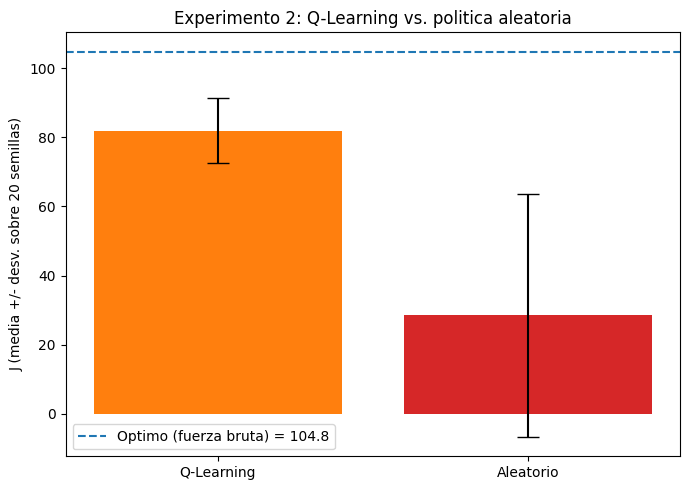

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
medias = [J_ql_finales.mean(), J_aleatorio_finales.mean()]
errores = [J_ql_finales.std(), J_aleatorio_finales.std()]
ax.bar(["Q-Learning", "Aleatorio"], medias, yerr=errores, capsize=8,
       color=[COLOR_QLEARNING, COLOR_ALEATORIO])
ax.axhline(J_lam, color=COLOR_FUERZA_BRUTA, linestyle="--",
           label=f"Optimo (fuerza bruta) = {J_lam:.1f}")
ax.set_ylabel(f"J (media +/- desv. sobre {N2} semillas)")
ax.set_title("Experimento 2: Q-Learning vs. politica aleatoria")
ax.legend()
fig.tight_layout()
ruta_exp2 = os.path.join(DIR_SALIDA, "cientifico_experimento2_qlearning.png")
fig.savefig(ruta_exp2, dpi=150)
print(f"Grafico guardado en {ruta_exp2}")
plt.show()

### 4. Analisis estadistico

In [7]:
t2, p2 = stats.ttest_ind(J_ql_finales, J_aleatorio_finales)
sp2 = np.sqrt((J_ql_finales.var() + J_aleatorio_finales.var()) / 2)
d2 = (J_ql_finales.mean() - J_aleatorio_finales.mean()) / sp2 if sp2 > 0 else float("inf")

print(f"t = {t2:.3f}, p = {p2:.4g}, d de Cohen = {d2:.3f}")
print("Se rechaza H0" if p2 < 0.05 else "No se rechaza H0 (con alpha=0.05)")

t = 6.397, p = 1.628e-07, d de Cohen = 2.075
Se rechaza H0


### 5. Conclusion

A diferencia del experimento 1, aqui la diferencia es contundente: con
t ≈ 6.4 y p ≈ 1.6×10⁻⁷ (muy por debajo de 0.05), **se rechaza H0**. El
tamano del efecto (d ≈ 2.1) es enorme segun la escala de Cohen. Q-Learning
no solo aprende algo mejor que el azar -- lo hace de forma consistente en
las 20 semillas, muy por encima de una politica aleatoria, aunque sigue
por debajo del optimo de fuerza bruta (queda en un maximo local, como ya se
discute en `horarios_simulacion.ipynb`).

**Contraste entre los dos experimentos:** el mismo procedimiento
(replicas + prueba t + tamano del efecto) da una conclusion clara en un
caso (Q-Learning sobre 8 bloques, mas grados de libertad, resultado muy
significativo) y una conclusion no concluyente en el otro (subasta sobre
5 tareas, poca variabilidad, resultado no significativo pese a un efecto
pequeno-mediano). Esa es precisamente la leccion metodologica de la
seccion de demostracion cientifica del reto de clase: **replicar y medir
el tamano del efecto, no solo mirar si "se ve mejor" en una corrida**.

## Conclusion general y limites de validez

- Ambos experimentos siguen el mismo ciclo de validacion (pregunta,
  hipotesis falsable, diseno con variables independiente/dependiente/
  control, replicas con semilla fija, prueba t + tamano del efecto,
  conclusion), lo que hace el resultado reproducible: correr esta celda con
  las mismas semillas siempre da los mismos numeros.
- **Limite de validez 1 (tamano del problema):** ambos casos de prueba son
  pequenos (4 agentes; 5 tareas u 8 bloques). Los resultados no deben
  extrapolarse a instancias mucho mas grandes sin repetir el experimento
  ahi -- el reto de clase lo senala explicitamente como un estudio de
  escalabilidad aparte.
- **Limite de validez 2 (una sola instancia del problema):** los dos casos
  (`construir_caso_ejemplo`, `construir_caso_asignacion`) son fijos. No se
  ha probado si las conclusiones se sostienen con otros agentes, bloques o
  tareas generados aleatoriamente.
- **Reproducibilidad:** todos los resultados de este notebook dependen
  unicamente de las semillas fijas 0..29 (experimento 1) y 0..19
  (experimento 2) y de `horarios_multiagente.py`; correr
  `python build_notebook_cientifico.py` seguido de la ejecucion completa
  del notebook reproduce exactamente estas cifras y graficas.